# Introduction

The purpose of this notebook is to explore the existing categorical aspects of the headline data and note down things that need to be cleaned prior to doing a combined analysis of headlines and stock data.

While `headlines.csv` will be the primary dataset used during model development, there are columns providing more information in most datasets. Of note, the `cnbc_deadlines.csv` contains a significant amount of metadata acquired during the scraping process and the `train.csv` and `test.csv` files contain some basic categorical data about news articles --- i.e., World, Sports, Business, Sci/Tech categories.

The exploration within these tight constraints will be used later to support arguments for any emerging model bias.

## Setup

We will be using common data science libraries listed below. Additionally, we plan to use `plotnine` as the data viz library to adhere to the grammar of graphics.

In [46]:
import pandas as pd
from plotnine import *

import re

from sector_study.config import RAW_DATA_DIR, EXTERNAL_DATA_DIR

print("setup complete!")

setup complete!


## Data

Included are the external data files, prefixed with `x_`, and the `headlines.csv` file, which preserves headlines; dates; and external data source.

There are three data repos from which the data is sourced. `train.csv` and `test.csv` data comes from a repo focused on news classification. The `*_headlines.csv` are from the a second repo claiming to represent the U.S. economy and stock market (sourcing The Guardian, CNBC, and Reuters) spanning from Jan 2018 to Jul 2020. The `cnbc_news_datase.csv` file is a more detailed dataset containing CNBC business and financial headlines from Dec 2006 to Oct 2021.

In [28]:
headlines = pd.read_csv(RAW_DATA_DIR.joinpath("headlines.csv"))

x_cnbc_news = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("cnbc_news_datase.csv"))
x_cnbc = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("cnbc_headlines.csv"))
x_guardian = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("guardian_headlines.csv"))
x_reuters = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("reuters_headlines.csv"))
x_test = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("test.csv"))
x_train = pd.read_csv(EXTERNAL_DATA_DIR.joinpath("train.csv"))

# Date-Time cleanup (see below)
# cleaning cnbc_news_datase.csv later
x_cnbc_news["published_at"] = pd.to_datetime(x_cnbc_news["published_at"], format='%Y-%m-%dT%H:%M:%S%z', utc=True)

# cleaning cnbc_headlines.csv later
x_cnbc["Time"] = (x_cnbc["Time"]
         .str.replace(r'\s+', ' ', regex=True)   # collapse all spaces
         .str.replace(r'(?<!\d)(\d)(?=[:\s])', r'0\1', regex=True)  # pad 0 for %I if needed
         .str.replace(r'(?<=\d{2}\s)(\w{3}).*(?=\s\d{4})', r'\1', regex=True)  # replace month with first three letters
         .str.replace(r'ET', '', regex=True)  # remove 'ET'
         .str.replace(r'\s(Mon|Tue|Wed|Thu|Fri|Sat|Sun),', '', regex=True)  # remove ' Mon,' etc.
         .str.strip())

x_cnbc["Time"] = pd.to_datetime(x_cnbc["Time"], format='%I:%M %p %d %b %Y')

# cleaning guardian_headlines.csv later
# x_guardian["Time"] = pd.to_datetime(x_guardian["Time"].str.strip(), format='%d-%b-%y')

# cleaning reuters_headlines.csv later
x_reuters["Time"] = pd.to_datetime(x_reuters["Time"], format='%b %d %Y', utc=True)

In [61]:
print(f"{x_cnbc_news.shape}\n{x_cnbc_news.columns}\n")
print(f"{x_cnbc.shape}\n{x_cnbc.columns}\n")
print(f"{x_guardian.shape}\n{x_guardian.columns}\n")
print(f"{x_reuters.shape}\n{x_reuters.columns}\n")
print(f"{x_test.shape}\n{x_test.columns}\n")
print(f"{x_train.shape}\n{x_train.columns}\n")
print(f"{headlines.shape}\n{headlines.columns}")

(625, 12)
Index(['index', 'title', 'url', 'published_at', 'author', 'publisher',
       'short_description', 'keywords', 'header_image', 'raw_description',
       'description', 'scraped_at'],
      dtype='object')

(3080, 3)
Index(['Headlines', 'Time', 'Description'], dtype='object')

(17800, 2)
Index(['Time', 'Headlines'], dtype='object')

(32770, 3)
Index(['Headlines', 'Time', 'Description'], dtype='object')

(7600, 3)
Index(['Class Index', 'Title', 'Description'], dtype='object')

(120000, 3)
Index(['Class Index', 'Title', 'Description'], dtype='object')

(181595, 3)
Index(['headline', 'date', 'source'], dtype='object')


The `headlines` preserves the only few columns that are kept in common among most datasets. However, `headlines` will be the focus of this exploration. The `x_*` data may be evaluated on a case-by-case basis if something interesting comes up during analysis.

In [30]:
headlines.head()

,headline,date,source
0,Santoli’s Wednesday market notes: Could Septem...,2021-09-29T17:09:39+0000,cnbc_news_datase
1,My take on the early Brexit winners and losers,2016-06-24T13:50:48-0400,cnbc_news_datase
2,Europe&#039;s recovery depends on Renzi&#039;s...,2014-03-25T13:29:45-0400,cnbc_news_datase
3,US Moves Closer to Becoming A Major Shareholde...,2009-04-22T19:49:03+0000,cnbc_news_datase
4,Trump: 'Mission accomplished' on 'perfectly ex...,2018-04-14T14:59:04+0000,cnbc_news_datase


# Exploration

There isn't a lot we can do without the aid of NLP. I think a lot of this notebook will be finding the dirty data. The obvious first place to look is for NAs.

In [31]:
print(headlines["headline"].isna().sum())

print("date value-counts:\n",
  headlines
    .loc[headlines["headline"].isna()]
    .value_counts("date")
)
print("source value-counts:\n",
  headlines
    .loc[headlines["headline"].isna()]
    .value_counts("source")
)

print(x_cnbc.shape)

280
date value-counts:
 Series([], Name: count, dtype: int64)
source value-counts:
 source
cnbc_headlines    280
Name: count, dtype: int64
(3080, 3)


So there are a few entries from `cnbc_headlines.csv` that had blank headlines and dates. Those can be easily removed.

In [32]:
headlines = headlines.loc[headlines["headline"].notna()]
headlines.describe()

,headline,date,source
count,181595,53995,181595
unique,175037,4725,6
top,Today's schedule,Mar 19 2020,train
freq,43,126,120000


## Dates

Looks like there is lots of overlap in the date column. That may permit the study to explore how different socio-political contexts play into the results. Perhaps some situation, like the 2008 depression, relates high volatility in the market and overly-cricial articles. With over 180,000 headlines, the possibilities are surely covered!

However, we must make sure that the computer sees dates as dates and not date-strings.

In [33]:
print(headlines["date"].describe())
print(headlines["date"].sample(10))
print(x_cnbc_news["published_at"].sample(3))
print(x_cnbc["Time"].sample(3))
print(x_guardian["Time"].sample(3))
print(x_reuters["Time"].sample(3))

count           53995
unique           4725
top       Mar 19 2020
freq              126
Name: date, dtype: object
22465     Jun 30 2020
32724     Nov 05 2019
93367             NaN
72192             NaN
86895             NaN
79670             NaN
109954            NaN
44786     Dec 17 2018
154635            NaN
61210             NaN
Name: date, dtype: object
445   2020-08-18 14:00:19+00:00
443   2012-03-16 13:16:28+00:00
163   2015-08-03 10:18:40+00:00
Name: published_at, dtype: datetime64[ns, UTC]
2117   2018-09-28 19:12:00
3033   2018-01-08 19:02:00
2530   2018-05-16 19:03:00
Name: Time, dtype: datetime64[ns]
1424    12-May-20
4994     7-Nov-19
4710    21-Nov-19
Name: Time, dtype: object
1601    2020-06-15 00:00:00+00:00
16650   2019-06-10 00:00:00+00:00
31801   2018-04-11 00:00:00+00:00
Name: Time, dtype: datetime64[ns, UTC]


Hmm... In my earnest to get the pipeline out of the way and get exploring, I forgot to convert the columns before I put them all together. Looks like there are 4 different date-time formats in this column, along with a bunch of `NaN`s from the `test.csv`/`train.csv` data source. For some God-forsaken reason, if there are times in the observation the locality is not guaranteed to be UTC timezone nor standard formatting!

In [8]:
# cleaning cnbc_news_datase.csv later
# pd.to_datetime(x_cnbc_news["published_at"], format='%Y-%m-%dT%H:%M:%S%z', utc=True)

In [9]:
# # cleaning cnbc_headlines.csv later
# clean = (x_cnbc["Time"]
#          .str.replace(r'\s+', ' ', regex=True)   # collapse all spaces
#          .str.replace(r'(?<!\d)(\d)(?=[:\s])', r'0\1', regex=True)  # pad 0 for %I if needed
#          .str.replace(r'(?<=\d{2}\s)(\w{3}).*(?=\s\d{4})', r'\1', regex=True)  # replace month with first three letters
#          .str.replace(r'ET', '', regex=True)  # remove 'ET'
#          .str.replace(r'\s(Mon|Tue|Wed|Thu|Fri|Sat|Sun),', '', regex=True)  # remove ' Mon,' etc.
#          .str.strip())

# x_cnbc["Time"] = pd.to_datetime(clean, format='%I:%M %p %d %b %Y')
# print(x_cnbc["Time"].head())


In [10]:
# cleaning guardian_headlines.csv later
# clean = x_guardian["Time"].str.strip()
# dt = pd.to_datetime(clean, format='%d-%b-%y', errors='coerce')

In [11]:
# cleaning reuters_headlines.csv later
# pd.to_datetime(x_reuters["Time"], format='%b %d %Y', utc=True)

In order to make a little forward progress, I've moved the above functions to the top. Everything should be proper date-time variables in the individual datasets. That should be sufficient to move forward with date (and time) analysis.

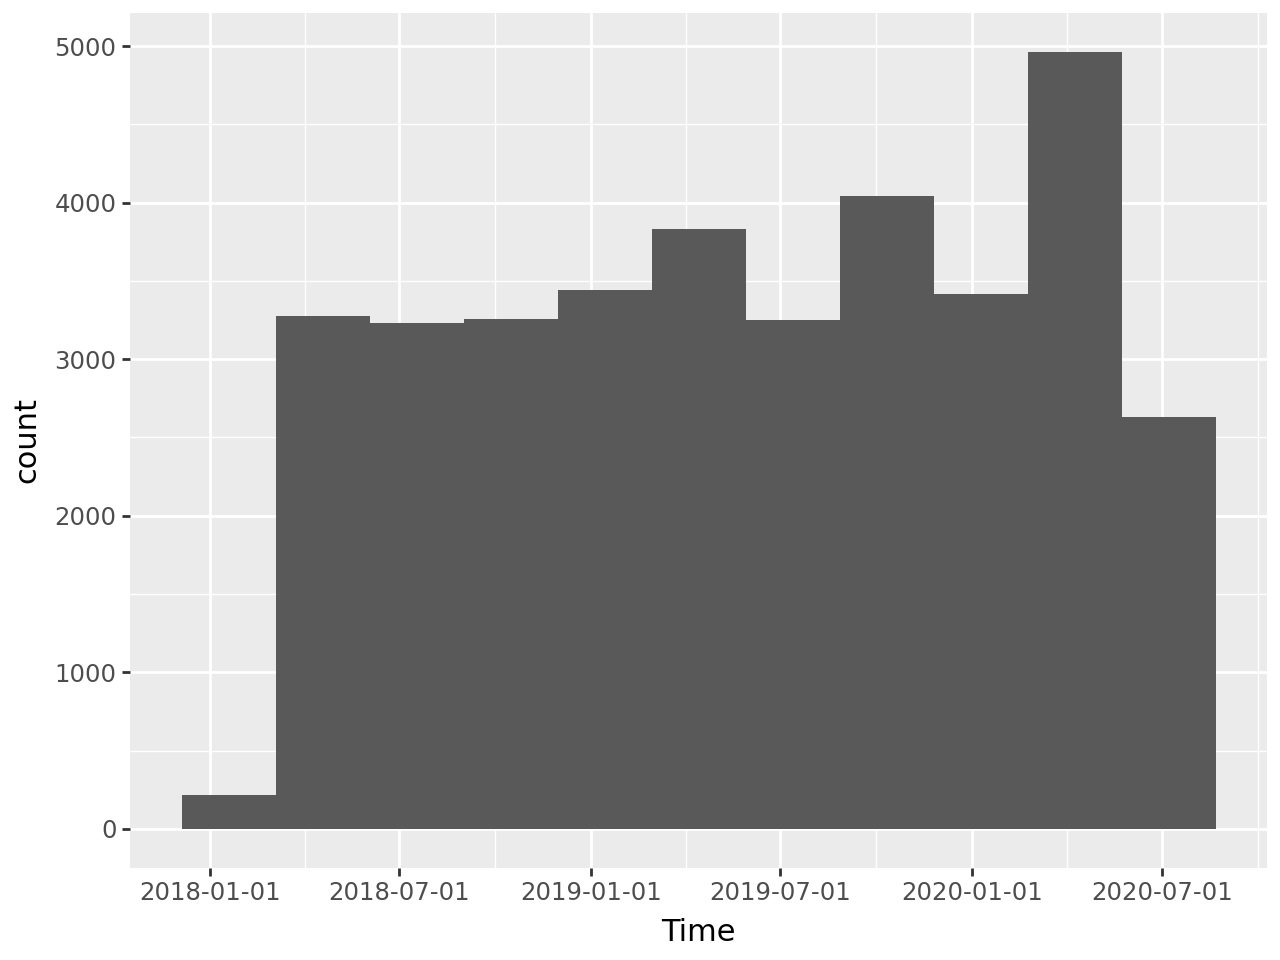

In [65]:
x_headlines_times = pd.concat([x_cnbc["Time"], x_reuters["Time"]])
x_headlines_times = pd.to_datetime(x_headlines_times, utc=True)

(
  ggplot(x_headlines_times.dropna().to_frame())
  + geom_histogram(aes(x="Time"), binwidth=90) # binwidth in days
)

Looks like we have a decently uniform random distribution here, from Jan 2018 to Jul 2020. Guardian data is excluded due to extensive data fixing during implementation, but is expected to accord. The bins for this histogram are 90 days wide and contain about 3,250 headlines in each bin.

So the `*_headlines.csv` data will be able to tell us how something like COVID-19 may change the relationship (perhaps marshal law would be a good generalization of the context?). Discovered relationships may differ between the first and second half of this time span because of the surrounding context.

Next is a similar histogram of the `cnbc_news_datase.csv`:

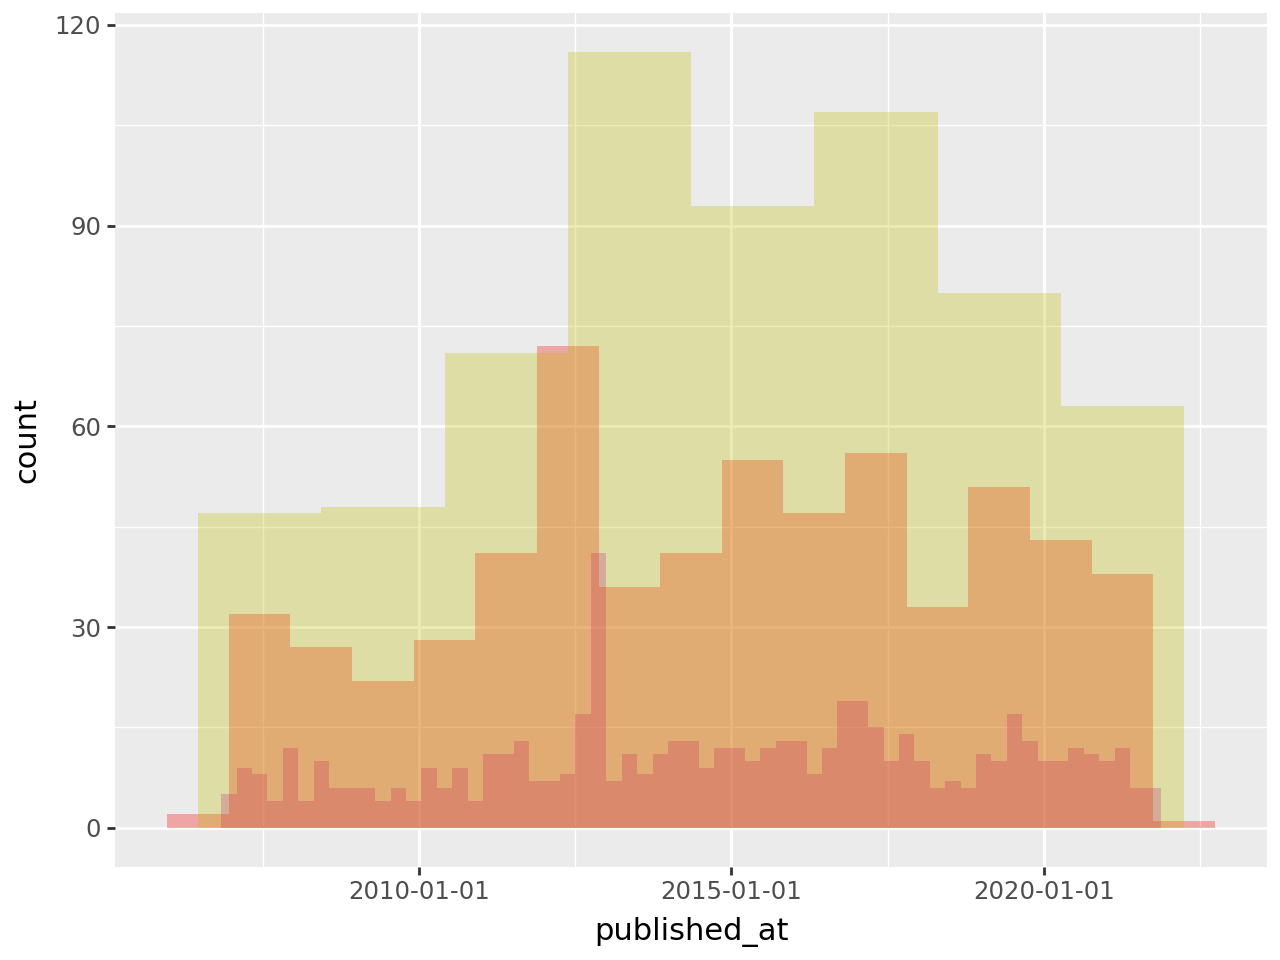

In [80]:
(
  ggplot(x_cnbc_news)
  + geom_histogram(aes(x="published_at"), binwidth=90, alpha=.3, fill="m")
  + geom_histogram(aes(x="published_at"), binwidth=360, alpha=.3, fill="r")
  + geom_histogram(aes(x="published_at"), binwidth=720, alpha=.3, fill="y")
)

This histogram shows that `cnbc_news_datase.csv` contains headlines accross approximatly 15 years of data. There is significant variation when binning the data by year (orange; `fill='r'`). But, binning by quarter (red; `fill='m'`) shows that there is general uniformity (maybe some subtle increase in frequency). A two-year bin (yellow; `fill='y'`) size shows that 2012-2018 were years with many news articles being published.

The spike around 2012 is interesting. I can't think of anything that might trigger a spike in news reports in the "final quarter" of 2012 (maybe elections? then where are the spikes for the other years'?).

## Discussion

Date-Time is one of the only common observations. Extensive efforts to ensure the dates and times are preserved through the data pipeline. However, there are some that don't include time.

TODO: analyze `test.csv`/`train.csv` categories

The `test.csv` and `train.csv` do not have date/time observations associated with their headlines. Further analysis of variables, the headline itself remains, requires heavy use of NLP. Hence, EDA for the headlines data should be contained to understanding how the dates might skew future analysis.

# Results

Having observations containing date-times will help in discovering how different contexts change relationships between headlines and other variables. Further, categorical usage of headlines (binning by month or hour) may further benefit the analysis. So there should be a larger focus on cleaning date-time variables in the pipeline.